# ShallowConvNet
This notebook explores the performance of the ShallowConvNet model on a classification task using EEG data.

Architecture is adapted from: Schirrmeister RT, Springenberg JT, Fiederer LDJ, Glasstetter M, Eggensperger K, Tangermann M, Hutter F, Burgard W, Ball T. Deep learning with convolutional neural networks for EEG decoding and visualization. Hum Brain Mapp. 2017 Nov;38(11):5391-5420. doi: 10.1002/hbm.23730. Epub 2017 Aug 7. PMID: 28782865; PMCID: PMC5655781.

In [ ]:
import os
IN_COLAB = "COLAB_GPU" in os.environ

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    base_path = "/content/drive/MyDrive/Colab Notebooks/cvae_project/"
    os.chdir(base_path)
else:
    base_path = "."

Mounted at /content/drive


In [ ]:
# Addresses some bug with gdown
!pip install --upgrade --no-cache-dir
# torchsummary is deprecated. Use torchinfo instead (https://github.com/TylerYep/torchinfo).
!pip install torchinfo

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import random

import torchinfo
import torch # import pytorch
import torch.nn as nn # pytorch's neural networks module
import torch.nn.functional as F # functional module.
from sklearn.model_selection import train_test_split


from torchinfo import summary #Displays information about network

import tqdm # for progress bar
import time

In [9]:
# See https://pytorch.org/docs/stable/notes/cuda.html
print(torch.cuda.is_available())
device_id = 0 if torch.cuda.is_available() else 'cpu' # Equivalent to device_id = 'cuda:0'
device = torch.device(device_id) # use these semantics to specify a specific device.

True


## (i) Loading and preprocessing the data

In [10]:
# Load data
person=-1
X_train_valid = np.load("data/X_train_valid.npy")
y_train_valid = np.load("data/y_train_valid.npy")
person_train_valid=np.load("data/person_train_valid.npy")
person_test=np.load("data/person_test.npy")
X_test = np.load("data/X_test.npy")
y_test = np.load("data/y_test.npy")
print (f'Training/Valid data shape: {X_train_valid.shape}')
print (f'Training/Valid labels shape: {y_train_valid.shape}')

if person != -1:
  X_train_valid=X_train_valid[(person_train_valid==person).flatten(),:,:]
  y_train_valid=y_train_valid[(person_train_valid==person).flatten()]
  X_test=X_test[(person_test==person).flatten(),:,:]
  y_test=y_test[(person_test==person).flatten()]
  print (f'Training/Valid data shape: {X_train_valid.shape}')
  print (f'Training/Valid labels shape: {y_train_valid.shape}')
  print (f'test data shape: {X_test.shape}')
  print (f'test labels shape: {y_test.shape}')


# Convert to 0-4 labeling and integer type (integers needed for categorical labels)
y_train_valid = (y_train_valid - np.min(y_train_valid)).astype('int')
y_test = (y_test - np.min(y_test)).astype('int')
X_train_np, X_val_np, y_train_np, y_val_np = train_test_split(X_train_valid, y_train_valid, test_size=0.2, random_state=12345)
X_train = torch.FloatTensor(X_train_np).to(device)
X_val = torch.FloatTensor(X_val_np).to(device)
y_train = torch.LongTensor(y_train_np).to(device)
y_val = torch.LongTensor(y_val_np).to(device)
X_test = torch.FloatTensor(X_test).to(device)
y_test = torch.LongTensor(y_test).to(device)

Training/Valid data shape: (2115, 22, 1000)
Training/Valid labels shape: (2115,)


In [11]:
class MyDataset(torch.utils.data.Dataset):
    '''
    Dataset wrapper to convert np arrays to PyTorch tensors
    making them iterable for dataloader.
    '''
    def __init__(self, X, Y):
        if isinstance(X, np.ndarray):
            self.X = torch.FloatTensor(X) # 32-bit float
        else:
            self.X = X
        if isinstance(Y, np.ndarray):
            self.Y = torch.LongTensor(Y) # integer type
        else:
            self.Y = Y
        return

    def __len__(self):
        return len(self.X)

    def __getitem__(self, index):
        return self.X[index], self.Y[index]

In [24]:
# Load data into network
batch_size = 64
train_dataset = MyDataset(X_train, y_train) #wraps raw tensors to a pytorch dataset object
train_dataloader = torch.utils.data.DataLoader(train_dataset, batch_size, shuffle=True)

val_dataset = MyDataset(X_val, y_val)
val_dataloader = torch.utils.data.DataLoader(val_dataset, batch_size, shuffle=False)

# TRAINING
print(f"Dataset size: {len(train_dataset)}")
print(f"X train dtype: {train_dataset.X.dtype}")
print(f"Y train dtype: {train_dataset.Y.dtype}")
print(f"X train shape: {train_dataset.X.shape}")
print(f"Y train shape: {train_dataset.Y.shape}")

# Single sample
X_sample, y_sample = train_dataset[0]
print(f"Single X shape: {X_sample.shape}")
print(f"Single y value: {y_sample}")

# Dataloader batch
X_batch, y_batch = next(iter(train_dataloader))
print(f"Batch X shape: {X_batch.shape}")
print(f"Batch y shape: {y_batch.shape}")

# VALIDATION
print(f"Dataset size: {len(val_dataset)}")
print(f"X valid dtype: {val_dataset.X.dtype}")
print(f"Y valid dtype: {val_dataset.Y.dtype}")
print(f"X valid shape: {val_dataset.X.shape}")
print(f"Y valid shape: {val_dataset.Y.shape}")

# Single sample
X_sample, y_sample = val_dataset[0]
print(f"Single X shape: {X_sample.shape}")
print(f"Single y value: {y_sample}")

# Dataloader batch
X_val_batch, y_val_batch = next(iter(val_dataloader))
print(f"Val Batch X shape: {X_val_batch.shape}")
print(f"Val Batch y shape: {y_val_batch.shape}")

Dataset size: 1692
X train dtype: torch.float32
Y train dtype: torch.int64
X train shape: torch.Size([1692, 22, 1000])
Y train shape: torch.Size([1692])
Single X shape: torch.Size([22, 1000])
Single y value: 2
Batch X shape: torch.Size([64, 22, 1000])
Batch y shape: torch.Size([64])
Dataset size: 423
X valid dtype: torch.float32
Y valid dtype: torch.int64
X valid shape: torch.Size([423, 22, 1000])
Y valid shape: torch.Size([423])
Single X shape: torch.Size([22, 1000])
Single y value: 1
Val Batch X shape: torch.Size([64, 22, 1000])
Val Batch y shape: torch.Size([64])


##(ii) Defining the Shallow Conv Net architecture
The image below is adapted from Figure 2. Shallow ConvNet architecture from the paper referenced to show the shape changes for this task. The changes are shown in red.

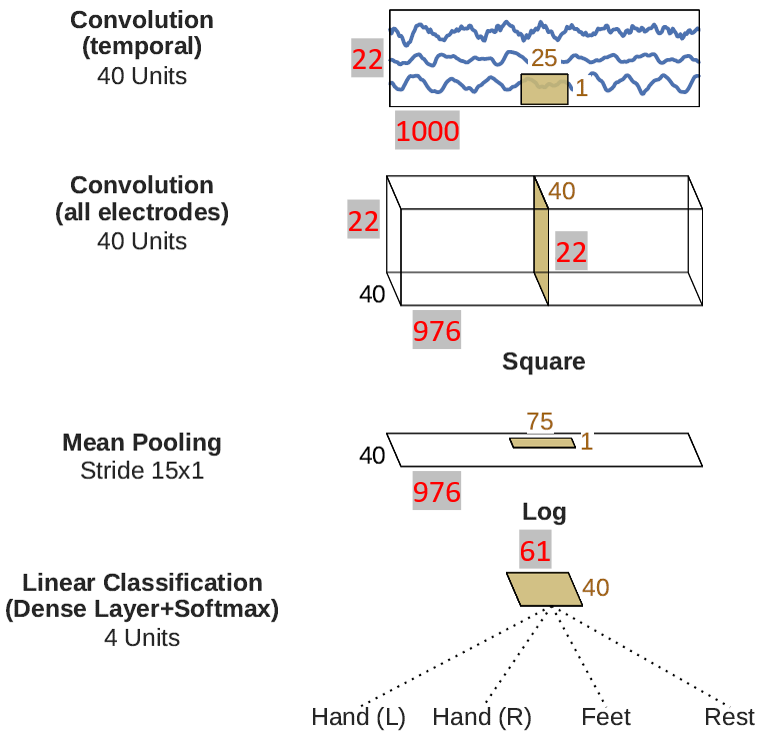

In [13]:
#from numpy.lib.function_base import hamming
# inherits from nn.Module
class ShallowConvNet(nn.Module):
    def __init__(self, input_shape=(22, 1000), n_temporal_filters=10, n_spatial_filters=40, n_classes=4,dropout=.3):
        super().__init__() # call __init__ method of superclass

        self.input_shape = input_shape # last two dimensions, (excluding batch size). Should be length 2.
        self.n_temporal_filters = n_temporal_filters
        self.n_spatial_filters = n_spatial_filters
        self.n_classes = n_classes
        self.dropout=dropout

        self.d = 2

        # https://pytorch.org/docs/stable/generated/torch.nn.Conv2d.html#torch.nn.Conv2d
        # torch.nn.Conv2d(in_channels, out_channels, kernel_size, stride=1, padding=0, dilation=1, groups=1, bias=True, padding_mode='zeros', device=None, dtype=None)
        self.temporal_convolution_15 = nn.Conv2d(1, n_temporal_filters*3, (1, 15), bias=False,padding='same')
        self.temporal_convolution_25 = nn.Conv2d(1, n_temporal_filters*2, (1, 25), bias=False,padding='same')
        self.temporal_convolution_35 = nn.Conv2d(1, n_temporal_filters, (1, 35), bias=False,padding='same')

        self.bn1 = nn.BatchNorm2d(n_temporal_filters*6)

        # Spatial convolution implemented as 2D (can be 1d, 2d, or 3d). We use 2d here.
        self.spatial_convolution = nn.Conv2d(n_temporal_filters*6, n_spatial_filters, (input_shape[0], 1))

        self.bn2 = nn.BatchNorm2d(n_spatial_filters)

        self.average_pool = nn.AvgPool2d((1, 75), stride=(1, 15))

        ## ADDED
        self.dropout = nn.Dropout(p=self.dropout)


        # Final linear layer
        # self.n_dense_features = n_spatial_filters*(1 + ((input_shape[1] - 25 + 1) - 75) // 15)
        # self.dense = nn.Linear(self.n_dense_features, n_classes)
        # you can also use 'self.dense = nn.LazyLinear(n_classes)' to avoid having to manually compute features
        self.dense = nn.LazyLinear(n_classes)
        self.elu = nn.ELU()
        return

    # declaring a forward method also makes the instance a callable.
    # e.g.:
    # model = ShallowConvNet()
    # out = model(x)
    def forward(self, x):
        # x has shape (batch_size, input_shape[0], input_shape[1])
        # Let H0 = input_shape[0], H1 = input_shape[1]
        h = x

        # note that h.view(-1, 1, h.shape[1], h.shape[2]) works normally but does not work with torchinfo
        # this is because the torchinfo input has a weird shape
        h = h.view(-1, 1, self.input_shape[0], self.input_shape[1]) # view as (batch_size, 1, input_shape[0], input_shape[1])
        # Sometimes, view doesn't work and you have to use reshape. This is because of how tensors are stored in memory.

        # 2d convolution takes inputs of shape (batch_size, num_channels, H, W)
        h_15 = self.temporal_convolution_15(h) # (batch_size, 1, H0, W0) -> (batch_size, n_temporal_filters, H0, W0 - 25 + 1)
        h_25 = self.temporal_convolution_25(h)
        h_35 = self.temporal_convolution_35(h)
        h=torch.cat((h_15,h_25,h_35), dim=1)
        # ADDED
        h = self.bn1(h)
        h = self.elu(h)

        h = self.spatial_convolution(h) # (batch_size, n_temporal_filters, H0, W0 - 25 + 1) -> (batch_size, n_spatial_filters, 1, W0 - 25 + 1)
        h = self.bn2(h)
        h = self.elu(h)
        h = h**2 # square; alternatively, use torch.pow(h, 2.0)

        h = self.average_pool(h) # (batch_size, n_spatial_filters, 1, W0 - 25 + 1) -> (batch_size, n_spatial_filters, 1, 1 + ((W0 - 25 + 1) - 75)//15)

        h = torch.log(h) # (natural) log

        h = h.view(h.shape[0], -1) # flatten the non-batch dimensions

        # ADDED
        h = self.dropout(h)
        h = self.dense(h) # (batch_size, self.n_dense_features) -> (batch_size, n_classes)

        # h = F.softmax(h, dim=1) NO NEED, nn.CrossEntropyLoss in pytorch combines log_softmax and NLLLoss internally in one operation

        return h



In [14]:
# Shows structure of network
print(summary(ShallowConvNet(), input_size=(22, 1000)))

Layer (type:depth-idx)                   Output Shape              Param #
ShallowConvNet                           [1, 4]                    --
├─Conv2d: 1-1                            [1, 30, 22, 1000]         450
├─Conv2d: 1-2                            [1, 20, 22, 1000]         500
├─Conv2d: 1-3                            [1, 10, 22, 1000]         350
├─BatchNorm2d: 1-4                       [1, 60, 22, 1000]         120
├─ELU: 1-5                               [1, 60, 22, 1000]         --
├─Conv2d: 1-6                            [1, 40, 1, 1000]          52,840
├─BatchNorm2d: 1-7                       [1, 40, 1, 1000]          80
├─ELU: 1-8                               [1, 40, 1, 1000]          --
├─AvgPool2d: 1-9                         [1, 40, 1, 62]            --
├─Dropout: 1-10                          [1, 2480]                 --
├─Linear: 1-11                           [1, 4]                    9,924
Total params: 64,264
Trainable params: 64,264
Non-trainable params: 0
Tota

##(iii) Training the model

In [25]:
# Seeding
# See https://pytorch.org/docs/stable/notes/randomness.html
#   and https://pytorch.org/docs/stable/generated/torch.use_deterministic_algorithms.html
torch.manual_seed(12345) # set the random seed for pytorch
random.seed(12345) # just in case
np.random.seed(12345) # just in case

#Make network
model = ShallowConvNet(n_temporal_filters=3, n_spatial_filters=10, n_classes=4).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=0.1)

# For one person
# model = ShallowConvNet(n_temporal_filters=3, n_spatial_filters=10, n_classes=4, dropout=.6).to(device)
# optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=0.2)

scheduler=torch.optim.lr_scheduler.StepLR(optimizer, step_size=40, gamma=0.25)
celoss = nn.CrossEntropyLoss()

num_epochs = 160
loss_hist = []
val_loss_hist = []
acc_hist = []
val_acc_hist = []
lr_hist=[]

In [ ]:
def save_net(name="shallowconvnet", use_time=True):
    if use_time:
        timestr = time.strftime("%Y%m%d-%H%M%S")
    else:
        timestr = ''

    save_dir = "weights/shallowconvnet"
    os.makedirs(save_dir, exist_ok=True)

    checkpoint = {
        'model':         model.state_dict(),
        'optimizer':     optimizer.state_dict(),
        'loss_hist':     loss_hist,
        'acc_hist':      acc_hist,
        'val_loss_hist': val_loss_hist,
        'val_acc_hist':  val_acc_hist,
        'epoch':         epoch,
    }
    save_path = os.path.join(save_dir, name + timestr + '.pt')
    torch.save(checkpoint, save_path)
    print(f"Saved checkpoint to {save_path}")

In [28]:
# Training
pbar = tqdm.tqdm(
    range(num_epochs), position=0, leave=True,
    bar_format='{l_bar}{bar:30}{r_bar}',
)
best_val = -1
for epoch in pbar:
    model.train()
    running_loss = 0.0
    for batch in train_dataloader:
        optimizer.zero_grad()
        x, y = batch
        out = model(x)
        loss = celoss(out, y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    loss_hist.append(running_loss / len(train_dataloader))
    lr_hist.append(scheduler.get_last_lr())

    model.eval()
    ns, nc = 0, 0
    with torch.no_grad():
        for batch in train_dataloader:
            x, y = batch
            out = model(x)
            ns += len(y)
            nc += (out.max(1)[1] == y).detach().cpu().numpy().sum()
    acc_hist.append(nc / ns)

    ns, nc = 0, 0
    running_val_loss = 0.0
    with torch.no_grad():
        for batch in val_dataloader:
            x, y = batch
            out = model(x)
            running_val_loss += celoss(out, y).item()
            ns += len(y)
            nc += (out.max(1)[1] == y).detach().cpu().numpy().sum()
    val_loss_hist.append(running_val_loss / len(val_dataloader))
    val_acc_hist.append(nc / ns)

    if val_acc_hist[-1] > best_val:
        best_val = val_acc_hist[-1]
        save_net("best_Shallow_Conv", False)
    scheduler.step()
    pbar.set_postfix({'acc': acc_hist[-1], 'val_acc': val_acc_hist[-1]})
    save_net("last_Shallow_Conv", False) # In case of a crash

  1%|▏                             | 1/160 [00:02<05:56,  2.24s/it, acc=0.373, val_acc=0.338]

Saved checkpoint to weights/shallowconvnet/best_Shallow_Conv.pt
Saved checkpoint to weights/shallowconvnet/last_Shallow_Conv.pt


  1%|▍                             | 2/160 [00:03<04:34,  1.74s/it, acc=0.441, val_acc=0.421]

Saved checkpoint to weights/shallowconvnet/best_Shallow_Conv.pt
Saved checkpoint to weights/shallowconvnet/last_Shallow_Conv.pt


  2%|▌                             | 3/160 [00:05<04:08,  1.58s/it, acc=0.484, val_acc=0.44]

...

Saved checkpoint to weights/shallowconvnet/last_Shallow_Conv.pt


 99%|█████████████████████████████▊| 159/160 [04:00<00:01,  1.55s/it, acc=0.866, val_acc=0.716]

Saved checkpoint to weights/shallowconvnet/last_Shallow_Conv.pt


100%|██████████████████████████████| 160/160 [04:01<00:00,  1.51s/it, acc=0.866, val_acc=0.728]

Saved checkpoint to weights/shallowconvnet/best_Shallow_Conv.pt
Saved checkpoint to weights/shallowconvnet/last_Shallow_Conv.pt


##(iv) Results, Evaluation and Metrics

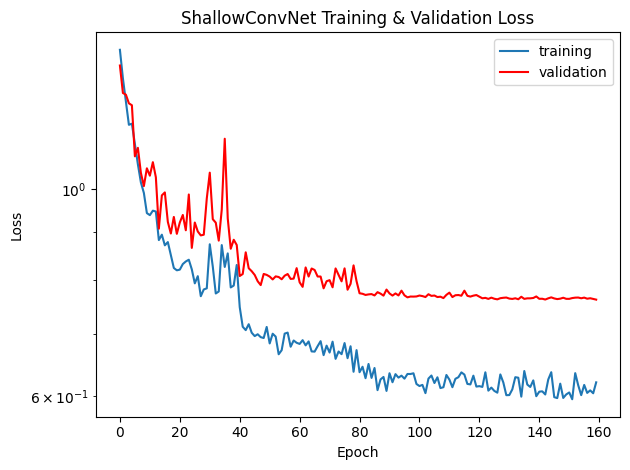

In [33]:
plt.figure(dpi=100)
plt.plot(loss_hist, label='training')
plt.plot(val_loss_hist, 'r', label='validation')
plt.yscale('log')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.title('ShallowConvNet Training & Validation Loss')
plt.legend()
plt.tight_layout()
plt.show()

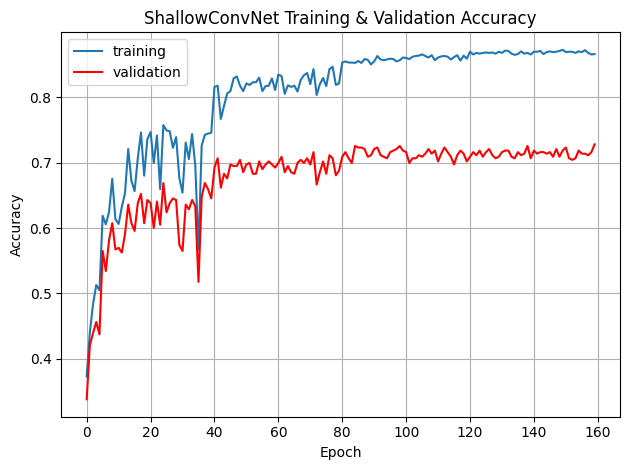

In [34]:
plt.figure(dpi=100)
plt.plot(acc_hist, label='training')
plt.plot(val_acc_hist, 'r', label='validation')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.title('ShallowConvNet Training & Validation Accuracy')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

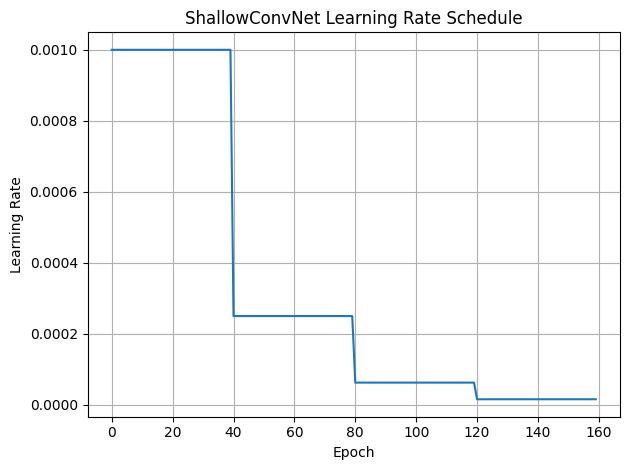

In [35]:
plt.figure(dpi=100)
plt.plot(lr_hist)
plt.xlabel('Epoch')
plt.ylabel('Learning Rate')
plt.title('ShallowConvNet Learning Rate Schedule')
plt.grid()
plt.tight_layout()
plt.show()

In [32]:
test_dataset = MyDataset(X_test, y_test)
test_dataloader = torch.utils.data.DataLoader(test_dataset, batch_size, shuffle=False) #batched iterator

model.eval() #mode switch to desable dropout and used the learned batchnorm statistics
ns, nc = 0, 0
test_loss = 0.0
with torch.no_grad(): # tells pytorch not to build a computational graph or store gradients
    for batch in test_dataloader:
        x, y = batch
        out = model(x)
        test_loss += celoss(out, y).item()
        ns += len(y) #add num samples in the batch to the total, batch size
        nc += (out.max(1)[1] == y).detach().cpu().numpy().sum() #num predictions that matched true labels in batch
test_accuracy = nc / ns
test_loss = test_loss / len(test_dataloader)
print(f"Test loss     : {test_loss:.4f}")
print(f"Test accuracy : {test_accuracy:.4f}")

Test loss     : 0.7629
Test accuracy : 0.7201


## Rerunning the model

In [ ]:
# Load best model checkpoint
checkpoint_path = "weights/shallowconvnet/best_Shallow_Conv.pt"

model = ShallowConvNet(
    n_temporal_filters=3,
    n_spatial_filters=10,
    n_classes=4
).to(device)

checkpoint = torch.load(checkpoint_path, map_location=device)
model.load_state_dict(checkpoint['model'])

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3,
    weight_decay=0.1
)

optimizer.load_state_dict(checkpoint['optimizer'])

loss_hist     = checkpoint['loss_hist']
acc_hist      = checkpoint['acc_hist']
val_loss_hist = checkpoint['val_loss_hist']
val_acc_hist  = checkpoint['val_acc_hist']
epoch         = checkpoint['epoch']

print(f"Loaded checkpoint from epoch {epoch}")
print(f"Best validation accuracy: {max(val_acc_hist):.4f}")